In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [2]:
df = pd.read_csv("../data/US_Accidents_March23.csv")

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
df.shape

(7728394, 46)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [6]:
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [7]:
df = df[[
    'Severity',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Amenity',
    'Bump',
    'Crossing',
    'Junction',
    'Traffic_Signal'
]]

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

Severity             0
Temperature(F)       0
Humidity(%)          0
Visibility(mi)       0
Wind_Speed(mph)      0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Junction             0
Traffic_Signal       0
dtype: int64

In [10]:
le = LabelEncoder()

df['Weather_Condition'] = le.fit_transform(df['Weather_Condition'])

In [11]:
X = df.drop('Severity', axis=1)

y = df['Severity']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = RandomForestClassifier()

In [14]:
df_sample = df.sample(n=100000, random_state=42)

In [15]:
X = df_sample.drop('Severity', axis=1)

y = df_sample['Severity']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [18]:
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.80435


In [21]:
joblib.dump(model, "../models/traffic_model.pkl")

['../models/traffic_model.pkl']

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.91      0.82      4073
           2       0.64      0.45      0.53      3906
           3       0.57      0.67      0.62      3996
           4       0.78      0.70      0.74      4025

    accuracy                           0.69     16000
   macro avg       0.69      0.68      0.68     16000
weighted avg       0.69      0.69      0.68     16000



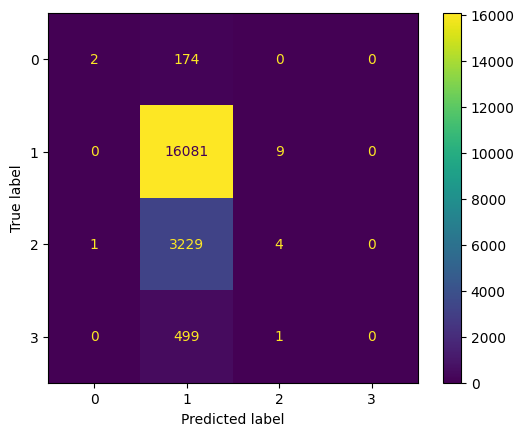

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [26]:
importance = model.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

print(feature_df)

             Feature  Importance
4  Weather_Condition    0.329263
3    Wind_Speed(mph)    0.208221
0     Temperature(F)    0.104526
7           Crossing    0.104402
1        Humidity(%)    0.095315
9     Traffic_Signal    0.088684
2     Visibility(mi)    0.039667
8           Junction    0.020811
5            Amenity    0.008066
6               Bump    0.001044


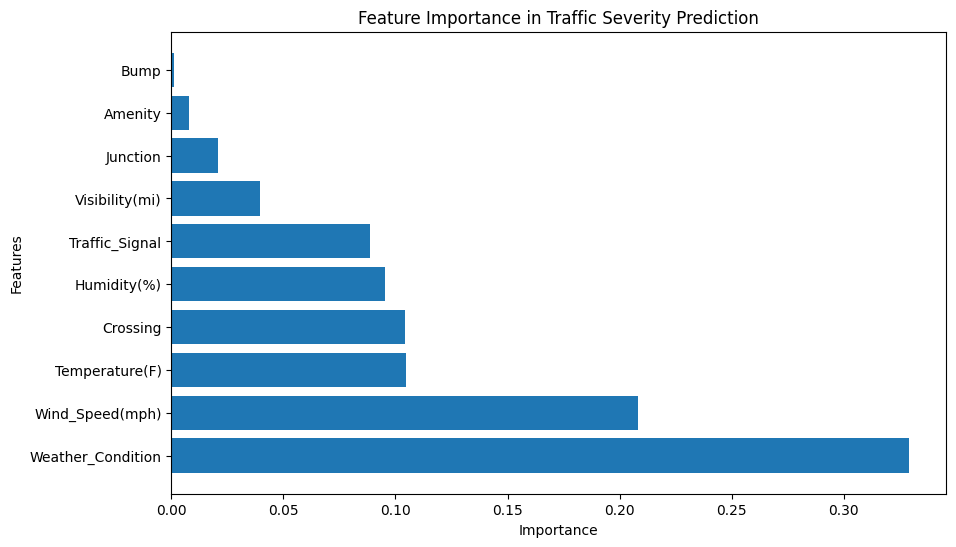

In [27]:
plt.figure(figsize=(10,6))

plt.barh(feature_df['Feature'], feature_df['Importance'])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Traffic Severity Prediction")

plt.show()

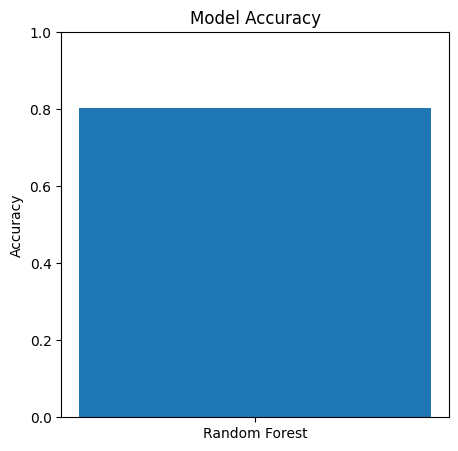

In [28]:
scores = [accuracy]

labels = ['Random Forest']

plt.figure(figsize=(5,5))

plt.bar(labels, scores)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.show()

In [29]:
df_sample['Severity'].value_counts()

Severity
2    80624
3    15920
4     2504
1      952
Name: count, dtype: int64

In [30]:
from sklearn.utils import resample

df_majority = df_sample[df_sample['Severity'] == 2]
df_minority_1 = df_sample[df_sample['Severity'] == 1]
df_minority_3 = df_sample[df_sample['Severity'] == 3]
df_minority_4 = df_sample[df_sample['Severity'] == 4]

df_majority_downsampled = resample(df_majority,
                                    replace=False,
                                    n_samples=20000,
                                    random_state=42)

df_minority_1_upsampled = resample(df_minority_1,
                                    replace=True,
                                    n_samples=20000,
                                    random_state=42)

df_minority_3_upsampled = resample(df_minority_3,
                                    replace=True,
                                    n_samples=20000,
                                    random_state=42)

df_minority_4_upsampled = resample(df_minority_4,
                                    replace=True,
                                    n_samples=20000,
                                    random_state=42)

df_balanced = pd.concat([
    df_majority_downsampled,
    df_minority_1_upsampled,
    df_minority_3_upsampled,
    df_minority_4_upsampled
])

In [31]:
X = df_balanced.drop('Severity', axis=1)
y = df_balanced['Severity']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.91      0.82      4073
           2       0.64      0.45      0.53      3906
           3       0.57      0.67      0.62      3996
           4       0.78      0.70      0.74      4025

    accuracy                           0.69     16000
   macro avg       0.69      0.68      0.68     16000
weighted avg       0.69      0.69      0.68     16000



In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6856875
Precision: 0.6858302569142731
Recall: 0.6856875
F1 Score: 0.6785248700327013


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.3915
Decision Tree Accuracy: 0.831
Random Forest Accuracy: 0.8566875


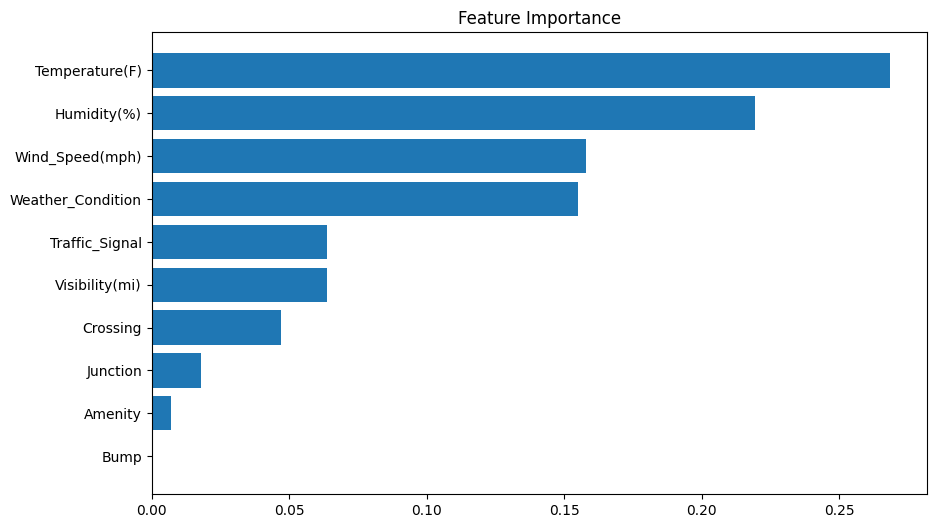

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance")
plt.show()

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions (make sure model is already trained)
y_pred = model.predict(X_test)

# ===== METRICS =====
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("===== MODEL PERFORMANCE =====")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

# ===== DETAILED REPORT =====
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

===== MODEL PERFORMANCE =====
Accuracy  : 0.6856875
Precision : 0.6858302569142731
Recall    : 0.6856875
F1 Score  : 0.6785248700327013

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           1       0.75      0.91      0.82      4073
           2       0.64      0.45      0.53      3906
           3       0.57      0.67      0.62      3996
           4       0.78      0.70      0.74      4025

    accuracy                           0.69     16000
   macro avg       0.69      0.68      0.68     16000
weighted avg       0.69      0.69      0.68     16000


Confusion Matrix:
 [[3696  114  238   25]
 [ 551 1758 1150  447]
 [ 326  635 2688  347]
 [ 327  247  622 2829]]


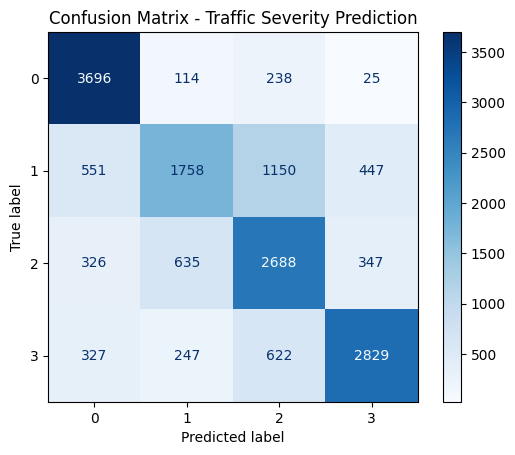

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Traffic Severity Prediction")
plt.show()